In [43]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

mkdir -p failed for path /gpfs/home/yb2612/.config/matplotlib: [Errno 13] Permission denied: '/gpfs/home/yb2612/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-yjvbpw0z because there was an issue with the default path (/gpfs/home/yb2612/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [36]:
markers = ["CD31", "E-cadherin", "CD68", "CD163", "MPO", "CD20", "CD3e", "CD8", "Granzyme B", "TOX", "CD4", "FOXP3", "TIM3"]
# samples = ["10103", "34933", "28873"]

def prep_imaging_data(raw_means_csv, metadata_csv, markers, sample_name):
    # load raw biomarker means, filter to markers of interest
    raw_means = pd.read_csv(raw_means_csv)
    print("no of cells:", raw_means.shape[0])
    raw_means_filtered = raw_means[markers]

    # load metadata, filter to abs x, y
    metadata = pd.read_csv(metadata_csv)
    metadata_xy = metadata[["absolute_x", "absolute_y"]].rename(columns={"absolute_x": "X", "absolute_y": "Y"})
    
    # join xy, raw means
    imaging_data = metadata_xy.join(raw_means_filtered)
    imaging_data.to_csv(f"/gpfs/data/proteomics/home/yb2612/data/celesta/cervical/imaging_data_{sample_name}.csv", index=False)

    return imaging_data

In [40]:
data_dir = "/gpfs/data/proteomics/home/yb2612/data/cervical_samples"
os.chdir(data_dir)

for folder in os.listdir():
    folder_path = os.path.join(data_dir, folder)
    if os.path.isdir(folder_path):
        # folder name is like 20250225-Jharna-02433-A1_Scan1.er
        try:
            sample_id = folder.split("-")[2]  # get string after 2nd split
            print(f"Sample ID: {sample_id}")
            
            raw_means_csv = os.path.join(folder_path, "raw_biomarker_means.csv")
            metadata_csv = os.path.join(folder_path, f"{folder}_metadata.csv")

            # Optional: check if files exist
            if os.path.exists(raw_means_csv):
                print(f"Found: {raw_means_csv}")
            else:
                print(f"Missing: {raw_means_csv}")
            
            if os.path.exists(metadata_csv):
                print(f"Found: {metadata_csv}")
            else:
                print(f"Missing: {metadata_csv}")
                
        except IndexError:
            print(f"Could not extract sample ID from folder name: {folder}")

        try:
            imaging_data = prep_imaging_data(raw_means_csv, metadata_csv, markers, f"{sample_id}_raw")
            print("saved imaging_data csv")
            
        except:
            print("could not make imaging_data")

Sample ID: 04738
Found: /gpfs/home/yb2612/yb2612_fenyo/data/cervical_samples/20250318-Jharna-04738-A1_Scan1.er/raw_biomarker_means.csv
Found: /gpfs/home/yb2612/yb2612_fenyo/data/cervical_samples/20250318-Jharna-04738-A1_Scan1.er/20250318-Jharna-04738-A1_Scan1.er_metadata.csv
no of cells: 402830
saved imaging_data csv
Sample ID: 09002
Found: /gpfs/home/yb2612/yb2612_fenyo/data/cervical_samples/20250305-Jharna-09002-A1_Scan1.er/raw_biomarker_means.csv
Found: /gpfs/home/yb2612/yb2612_fenyo/data/cervical_samples/20250305-Jharna-09002-A1_Scan1.er/20250305-Jharna-09002-A1_Scan1.er_metadata.csv
no of cells: 194345
saved imaging_data csv
Sample ID: 07611
Found: /gpfs/home/yb2612/yb2612_fenyo/data/cervical_samples/20250225-Jharna-07611-A3_Scan1.er/raw_biomarker_means.csv
Found: /gpfs/home/yb2612/yb2612_fenyo/data/cervical_samples/20250225-Jharna-07611-A3_Scan1.er/20250225-Jharna-07611-A3_Scan1.er_metadata.csv
no of cells: 1368196
saved imaging_data csv
Sample ID: 34933
Found: /gpfs/home/yb2612/

In [41]:
# display sample df
sample = pd.read_csv("/gpfs/data/proteomics/home/yb2612/data/celesta/cervical/imaging_data_10103_raw.csv")
sample

,X,Y,CD31,E-cadherin,CD68,CD163,MPO,CD20,CD3e,CD8,Granzyme B,TOX,CD4,FOXP3,TIM3
0,16650.105263,2818.000000,2.350877,0.052632,129.122803,0.000000,9.350877,7.929824,93.842102,0.000000,0.000000,0.000000,577.824585,25.052631,34.491226
1,16667.611111,2820.675214,10.448718,4.072649,274.363251,0.008547,19.846153,30.602564,149.252136,0.547009,3.196581,9.521367,1901.217896,182.970093,46.286324
2,16686.848837,2818.116279,20.348837,2.744186,201.023254,0.000000,35.837208,18.976744,106.651161,0.000000,1.395349,3.220930,890.465088,79.046509,111.046509
3,16751.000000,2817.142857,4.678571,92.750000,173.964279,0.000000,463.892853,5.821429,67.000000,5.535714,6.964286,3.035714,474.214294,74.571426,4.500000
4,16720.200000,2818.676923,5.169231,0.415385,303.815399,0.000000,8.153846,6.030769,62.061539,0.000000,0.015385,1.923077,804.200012,41.830769,395.123077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16627,3120.167763,13294.319079,13.638158,49.486843,100.144737,0.417763,85.789474,63.815788,76.151314,21.381578,4.654605,16.055922,315.717102,124.180923,653.207214
16628,3081.238372,13295.761628,5.877907,2.081395,6.069767,0.000000,19.965117,1.936046,14.453488,0.000000,0.087209,0.302326,10.325582,3.168605,0.139535
16629,3187.969388,13298.321429,12.576530,805.515320,101.704079,0.214286,136.918365,40.387756,115.250000,4.688776,7.250000,47.025509,505.341827,199.045914,30.433674
16630,3200.673981,13300.642633,5.250784,158.300934,52.219437,0.382445,43.257053,32.623825,50.304073,1.266458,5.526646,17.084639,127.909088,82.652039,15.159875


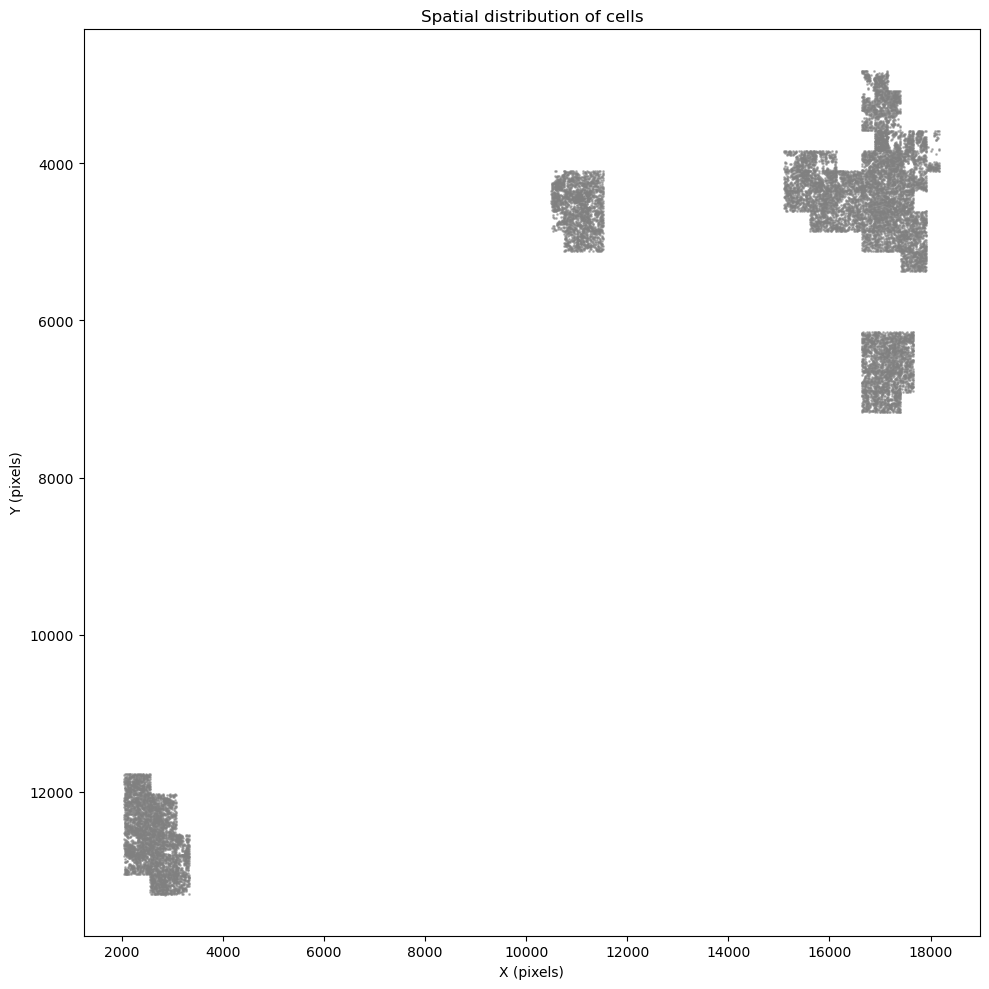

In [44]:
# Plot X vs Y
plt.figure(figsize=(10, 10))
plt.scatter(sample['X'], sample['Y'], s=1, alpha=0.5, c='gray')  # small dots, slightly transparent
plt.gca().invert_yaxis()  # optional: invert Y-axis to match image coordinate system
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.title("Spatial distribution of cells")
plt.tight_layout()
plt.show()